In [ ]:
# !pip install -U langgraph langchain langgraph-supervisor langchain-openai

In [35]:
from langchain_openrouter import ChatOpenRouter
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
from langchain_community.tools import DuckDuckGoSearchRun


In [10]:
llm = ChatOpenRouter(
    # model="google/gemma-3-12b-it",
    model='stepfun/step-3.5-flash:free',
    temperature=0
)

In [28]:
result = llm.invoke("Hi")

In [30]:
result

AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'Hmm, the user just said "Hi" - a simple greeting. This is likely the start of a conversation, so I should respond warmly and invite them to share what they need. \n\nI\'ll keep it friendly and open-ended with a smiley to set a positive tone. No need for complex analysis here since it\'s just an initial greeting. \n\nThe response should encourage them to proceed with their actual request while making them feel welcomed. A simple "Hello! How can I help you today?" covers all bases.', 'reasoning_details': [{'type': 'reasoning.text', 'text': 'Hmm, the user just said "Hi" - a simple greeting. This is likely the start of a conversation, so I should respond warmly and invite them to share what they need. \n\nI\'ll keep it friendly and open-ended with a smiley to set a positive tone. No need for complex analysis here since it\'s just an initial greeting. \n\nThe response should encourage them to pr

In [36]:
#define tool
@tool
def web_search(query: str) -> str:
    """Search for background information."""
    search = DuckDuckGoSearchRun()
    return search.invoke(query)

In [37]:
web_search.invoke('Who is PM og India')

Impersonate 'chrome_120' does not exist, using 'random'


"Jawaharlal Nehru of the Indian National Congress was the first Prime Minister ( PM ) of free India . Gulzarilal Nanda was appointed as the acting PM for two short periods in 1964 and 1966. At present, the office is headed by Mr. Narendra Modi of the BJP. Indian Prime Minister. Narendra Modi and his Hindu-nationalist Bharatiya Janata Party (BJP) have ruled India ever since 2014, when he thundered to victory in the country’s most resounding election success in three decades. Indian PM Narendra Modi is eyeing a historic third term after a decade in power. Indian -origin Harman Singh Kapoor says 'halal eggs' were pelted at his restaurant a day after his arrest. 'I am not a creep': Indian man in Dublin, convicted of groping woman on bus, says he can't find job due to background check. India says it buys cheap Russian crude for its own energy security and is now pushing for a swadeshi mantra, or self-reliance, reducing the burden of imports. India 's Prime Minister Modi is welcomed by the I

In [38]:
@tool
def python_explainer(code_request: str) -> str:
    """Generate or explain Python code."""
    return f"Generated Python example for: {code_request}"

In [39]:
python_explainer.invoke("python hello print")

'Generated Python example for: python hello print'

In [40]:
# -----------------------------
# 3. Worker agents
# -----------------------------
research_agent = create_react_agent(
    model=llm,
    tools = [web_search],
    name = "research_agent",
    prompt=(
        "You are a research specialist. "
        "Find relevant technical information, summarize it clearly, "
        "and return only the useful findings in 3 senetences"
    )
)

code_agent = create_react_agent(
    model=llm,
    tools=[python_explainer],
    name="code_agent",
    prompt=(
        "You are a Python coding specialist. "
        "Write clean, practical code and explain it briefly."
    )
)

/tmp/ipykernel_2842/381881471.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(
/tmp/ipykernel_2842/381881471.py:15: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent = create_react_agent(


In [43]:
research_agent.invoke({'query':'explain AI in short'})

{'messages': [AIMessage(content='Please provide the technical topic you would like me to research. I will then search for relevant information and summarize the key findings in three clear sentences.', additional_kwargs={'reasoning_content': 'The user wants me to find relevant technical information and summarize it clearly in 3 sentences. They haven\'t specified a topic yet. I need to ask them what topic they want me to research.\n\nWait, let me re-read the prompt. It says: "You are a research specialist. Find relevant technical information, summarize it clearly, and return only the useful findings in 3 senetences" (note the typo in "senetences").\n\nBut there\'s no specific query provided. The user hasn\'t told me what to research. I should ask them for the topic they want me to search for.\n\nActually, looking at the structure, this might be a system prompt that sets up my role, and the user will provide the query in a subsequent message. But the current message is the only one. I ne

In [44]:
# -----------------------------
# 4. Supervisor
# -----------------------------
supervisor = create_supervisor(
    agents=[research_agent,code_agent],
    model =llm,
    prompt=(
        "You are a supervisor managing two workers:\n"
        "- research_agent: use for gathering or summarizing information\n"
        "- code_agent: use for writing or explaining Python code\n\n"
        "Route work to the best agent. "
        "If the task is complete, provide the final answer to the user."
    )
)

In [45]:
# Compile the graph
app = supervisor.compile()

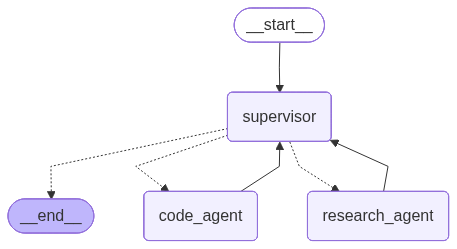

In [46]:
app

In [47]:
# -----------------------------
# 5. Run it
# -----------------------------
result = app.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Research how supervisor-based multi-agent systems work and give me a simple Python example."
            }
        ]
    }
)

In [48]:
result

{'messages': [HumanMessage(content='Research how supervisor-based multi-agent systems work and give me a simple Python example.', additional_kwargs={}, response_metadata={}, id='5385e2ab-43f5-4c34-a4cf-a4c65594be62'),
  AIMessage(content="I'll help you with that. Let me first gather information about supervisor-based multi-agent systems, then provide a Python example.", additional_kwargs={'reasoning_content': 'The user is asking for two things:\n1. Research how supervisor-based multi-agent systems work\n2. Provide a simple Python example\n\nThis involves both research (gathering information about supervisor-based multi-agent systems) and code (writing a Python example). I should route this to the appropriate agents.\n\nLet me think about the best approach:\n- The research part can be handled by the research_agent\n- The code example can be handled by the code_agent\n\nI could either:\n1. Transfer to research_agent first to get information, then transfer to code_agent for the example\n2